In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/project57634/project1/qwen2vl_accuracy.csv
/kaggle/input/datasets/project57634/project1/llava_accuracy.csv
/kaggle/input/datasets/project57634/project1/paligemma_accuracy.csv
/kaggle/input/datasets/project57634/project1/phi3_accuracy.csv


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os

print("All input folders:", os.listdir("/kaggle/input"))

base_path = os.path.join("/kaggle/input", os.listdir("/kaggle/input")[0])
print("Using:", base_path)
print("Files:", os.listdir(base_path))

All input folders: ['datasets']
Using: /kaggle/input/datasets
Files: ['project57634']


In [4]:
import os

print("Top level in /kaggle/input:")
print(os.listdir("/kaggle/input"))

for folder in os.listdir("/kaggle/input"):
    full = os.path.join("/kaggle/input", folder)
    print("\nFolder:", full)
    print(os.listdir(full))

Top level in /kaggle/input:
['datasets']

Folder: /kaggle/input/datasets
['project57634']


In [5]:
base_path = "/kaggle/input/datasets/project57634"

In [6]:
import os
import pandas as pd

wanted_files = [
    "phi3_accuracy.csv",
    "qwen2vl_accuracy.csv",
    "blip2_accuracy.csv",
    "llava_accuracy.csv",
    "paligemma_accuracy.csv"
]

found = {}

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f in wanted_files:
            found[f] = os.path.join(root, f)

print("Found files:")
for k, v in found.items():
    print(k, "->", v)

Found files:
qwen2vl_accuracy.csv -> /kaggle/input/datasets/project57634/project1/qwen2vl_accuracy.csv
llava_accuracy.csv -> /kaggle/input/datasets/project57634/project1/llava_accuracy.csv
paligemma_accuracy.csv -> /kaggle/input/datasets/project57634/project1/paligemma_accuracy.csv
phi3_accuracy.csv -> /kaggle/input/datasets/project57634/project1/phi3_accuracy.csv


In [7]:
phi = pd.read_csv(found["phi3_accuracy.csv"])
qwen = pd.read_csv(found["qwen2vl_accuracy.csv"])
llava = pd.read_csv(found["llava_accuracy.csv"])
paligemma = pd.read_csv(found["paligemma_accuracy.csv"])

In [8]:
phi["model"] = "Phi-3"
qwen["model"] = "Qwen2-VL"
llava["model"] = "LLaVA"
paligemma["model"] = "PaliGemma"

final_compare_df = pd.concat(
    [phi, qwen, llava, paligemma],
    ignore_index=True
)

final_compare_df = final_compare_df[["model", "category", "light", "accuracy_percent"]]

print("FINAL COMPARISON TABLE")
print(final_compare_df)

FINAL COMPARISON TABLE
        model                 category  light  accuracy_percent
0       Phi-3          Object Counting    day              65.0
1       Phi-3          Object Counting  night              71.0
2       Phi-3       Object Description    day              13.0
3       Phi-3       Object Description  night              13.0
4       Phi-3  Surrounding Description    day              76.0
5       Phi-3  Surrounding Description  night              37.0
6    Qwen2-VL          Object Counting    day              71.0
7    Qwen2-VL          Object Counting  night              70.0
8    Qwen2-VL       Object Description    day              20.0
9    Qwen2-VL       Object Description  night              16.0
10   Qwen2-VL  Surrounding Description    day              77.0
11   Qwen2-VL  Surrounding Description  night              42.0
12      LLaVA          Object Counting    day              67.0
13      LLaVA          Object Counting  night              74.0
14      LLaVA    

In [9]:
import os

OUTPUT_DIR = "/kaggle/working/final_model_comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

final_compare_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_all_models_comparison.csv"),
    index=False
)

print("Saved final table")
print(os.listdir(OUTPUT_DIR))

Saved final table
['final_all_models_comparison.csv']


In [10]:
summary_table = final_compare_df.pivot_table(
    index=["model", "category"],
    columns="light",
    values="accuracy_percent"
).reset_index()

print(summary_table)

summary_table.to_csv(
    os.path.join(OUTPUT_DIR, "final_summary_table.csv"),
    index=False
)

light      model                 category   day  night
0          LLaVA          Object Counting  67.0   74.0
1          LLaVA       Object Description  19.0   17.0
2          LLaVA  Surrounding Description  56.0   24.0
3      PaliGemma          Object Counting  74.0   74.0
4      PaliGemma       Object Description  11.0    9.0
5      PaliGemma  Surrounding Description  56.0   16.0
6          Phi-3          Object Counting  65.0   71.0
7          Phi-3       Object Description  13.0   13.0
8          Phi-3  Surrounding Description  76.0   37.0
9       Qwen2-VL          Object Counting  71.0   70.0
10      Qwen2-VL       Object Description  20.0   16.0
11      Qwen2-VL  Surrounding Description  77.0   42.0


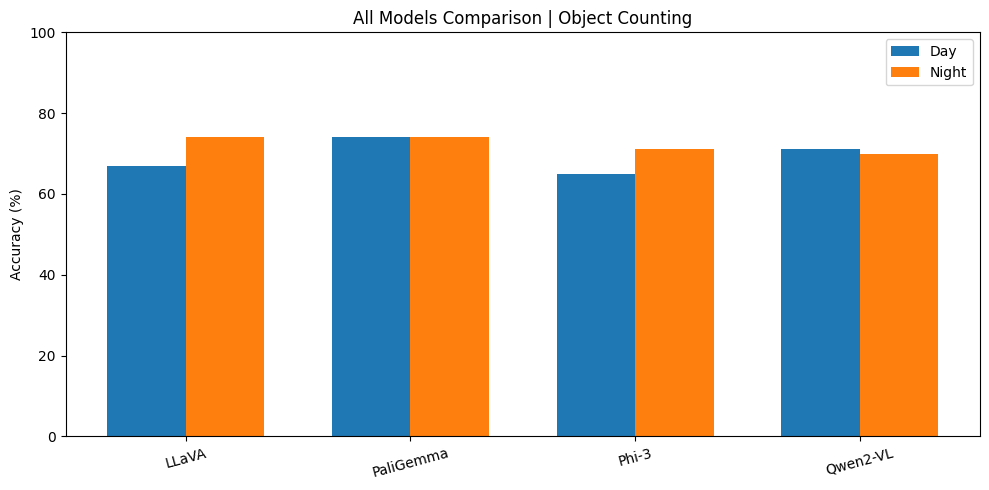

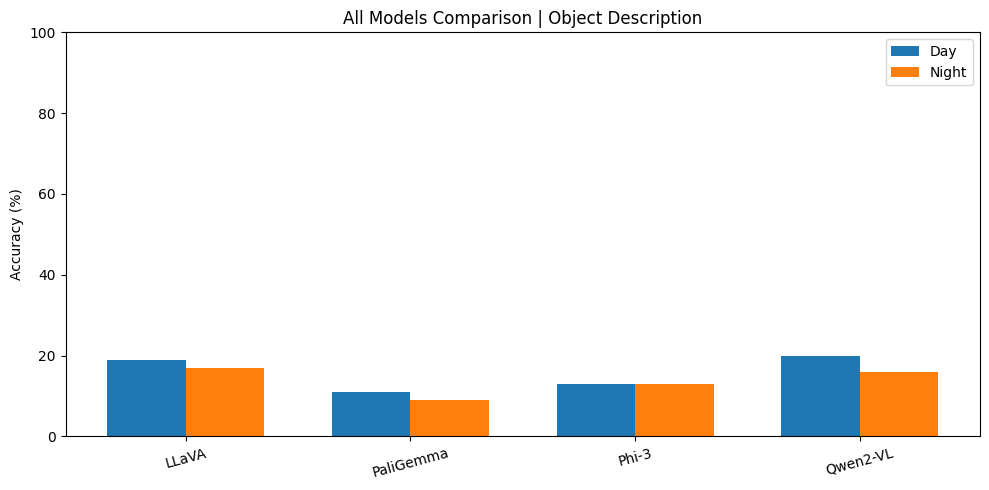

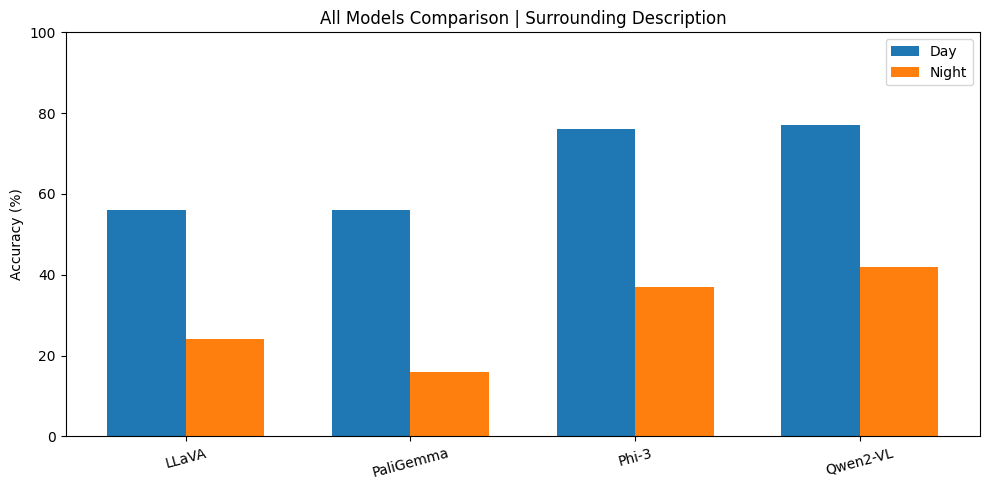

In [11]:
import matplotlib.pyplot as plt
import numpy as np

for category in final_compare_df["category"].unique():
    sub = final_compare_df[final_compare_df["category"] == category].copy()
    pivot = sub.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

    x = np.arange(len(pivot))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, pivot["day"], width, label="Day")
    plt.bar(x + width/2, pivot["night"], width, label="Night")

    plt.xticks(x, pivot["model"], rotation=15)
    plt.ylabel("Accuracy (%)")
    plt.title(f"All Models Comparison | {category}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"all_models_{category.replace(' ', '_').lower()}.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

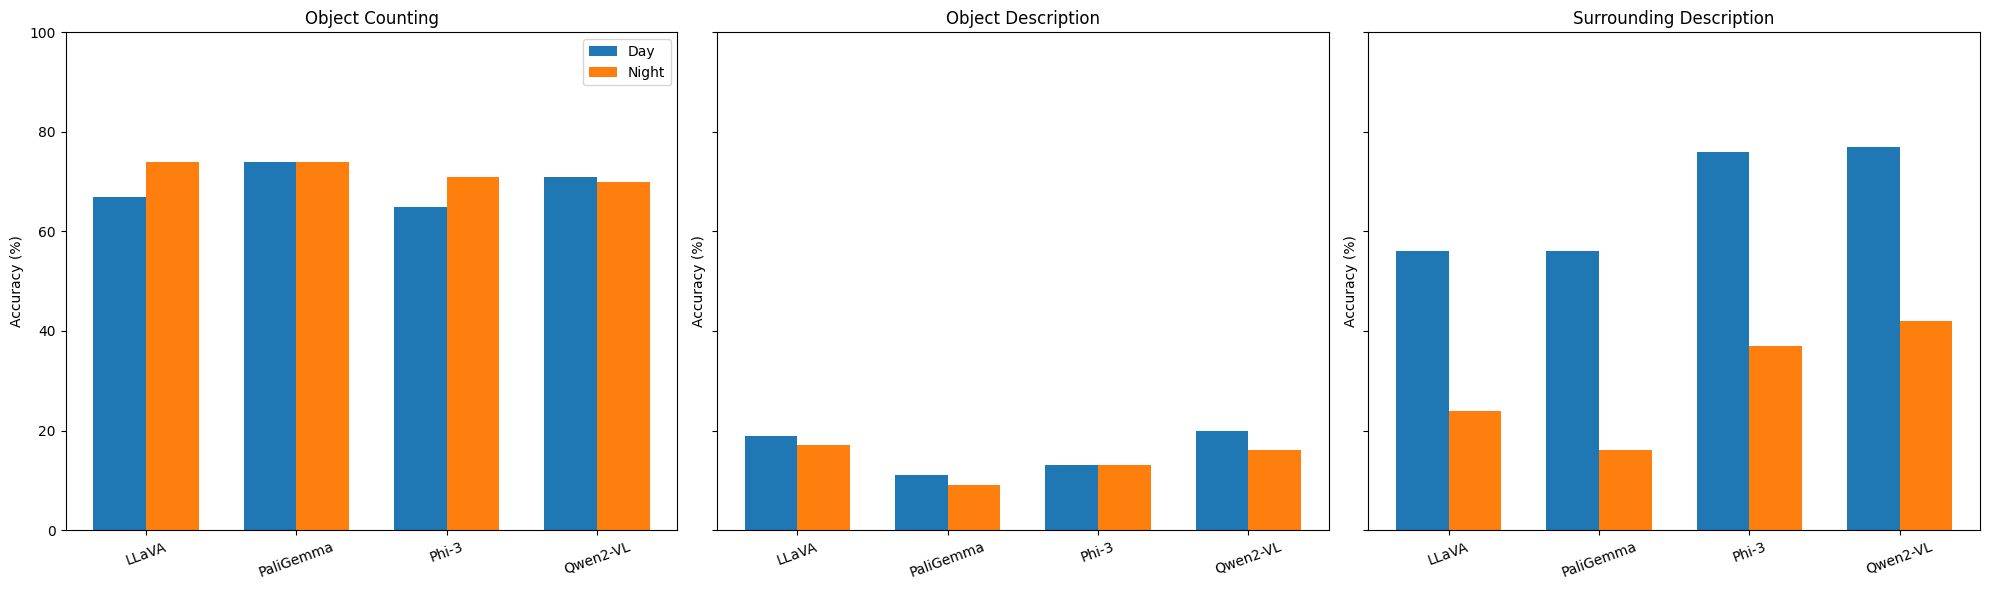

Saved: /kaggle/working/final_model_comparison/all_5_models_combined_chart.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

categories = final_compare_df["category"].unique()

for ax, category in zip(axes, categories):
    sub = final_compare_df[final_compare_df["category"] == category].copy()
    pivot = sub.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

    x = np.arange(len(pivot))
    width = 0.35

    ax.bar(x - width/2, pivot["day"], width, label="Day")
    ax.bar(x + width/2, pivot["night"], width, label="Night")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot["model"], rotation=20)
    ax.set_title(category)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)

axes[0].legend()
plt.tight_layout()

combined_png = os.path.join(OUTPUT_DIR, "all_5_models_combined_chart.png")
plt.savefig(combined_png, dpi=200)
plt.show()

print("Saved:", combined_png)

In [13]:
overall_accuracy = (
    final_compare_df
    .groupby("model")["accuracy_percent"]
    .mean()
    .reset_index()
    .sort_values("accuracy_percent", ascending=False)
)

overall_accuracy["accuracy_percent"] = overall_accuracy["accuracy_percent"].round(2)

print("OVERALL ACCURACY TABLE")
print(overall_accuracy)

OVERALL ACCURACY TABLE
       model  accuracy_percent
3   Qwen2-VL             49.33
2      Phi-3             45.83
0      LLaVA             42.83
1  PaliGemma             40.00


In [14]:
OUTPUT_DIR = "/kaggle/working/final_model_comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

overall_accuracy.to_csv(
    os.path.join(OUTPUT_DIR, "overall_accuracy_all_5_models.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "overall_accuracy_all_5_models.csv"))

Saved: /kaggle/working/final_model_comparison/overall_accuracy_all_5_models.csv


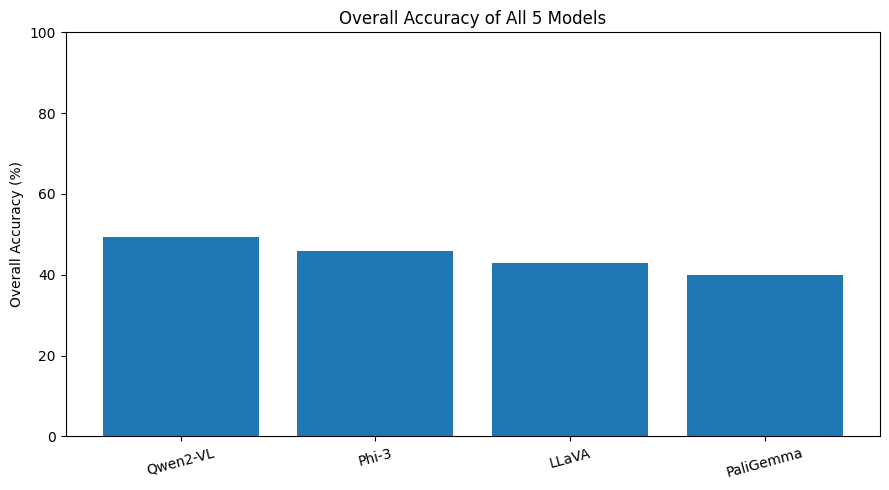

Saved: /kaggle/working/final_model_comparison/overall_accuracy_all_5_models_bar.png


In [15]:
plt.figure(figsize=(9, 5))
plt.bar(overall_accuracy["model"], overall_accuracy["accuracy_percent"])
plt.ylabel("Overall Accuracy (%)")
plt.title("Overall Accuracy of All 5 Models")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()

bar_path = os.path.join(OUTPUT_DIR, "overall_accuracy_all_5_models_bar.png")
plt.savefig(bar_path, dpi=200)
plt.show()

print("Saved:", bar_path)

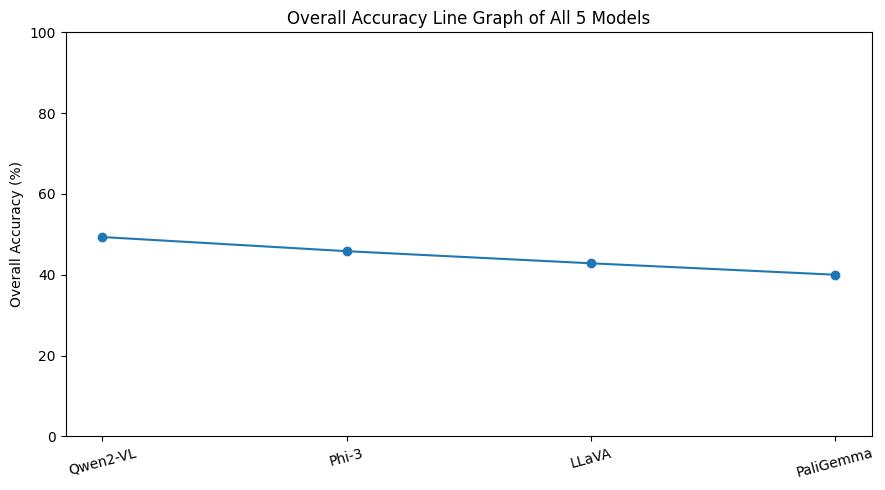

Saved: /kaggle/working/final_model_comparison/overall_accuracy_all_5_models_line.png


In [16]:
plt.figure(figsize=(9, 5))
plt.plot(overall_accuracy["model"], overall_accuracy["accuracy_percent"], marker="o")
plt.ylabel("Overall Accuracy (%)")
plt.title("Overall Accuracy Line Graph of All 5 Models")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()

line_path = os.path.join(OUTPUT_DIR, "overall_accuracy_all_5_models_line.png")
plt.savefig(line_path, dpi=200)
plt.show()

print("Saved:", line_path)

In [17]:
day_night_overall = (
    final_compare_df
    .groupby(["model", "light"])["accuracy_percent"]
    .mean()
    .reset_index()
)

day_night_overall["accuracy_percent"] = day_night_overall["accuracy_percent"].round(2)

print("DAY vs NIGHT OVERALL TABLE")
print(day_night_overall)

day_night_overall.to_csv(
    os.path.join(OUTPUT_DIR, "day_night_overall_all_5_models.csv"),
    index=False
)

DAY vs NIGHT OVERALL TABLE
       model  light  accuracy_percent
0      LLaVA    day             47.33
1      LLaVA  night             38.33
2  PaliGemma    day             47.00
3  PaliGemma  night             33.00
4      Phi-3    day             51.33
5      Phi-3  night             40.33
6   Qwen2-VL    day             56.00
7   Qwen2-VL  night             42.67


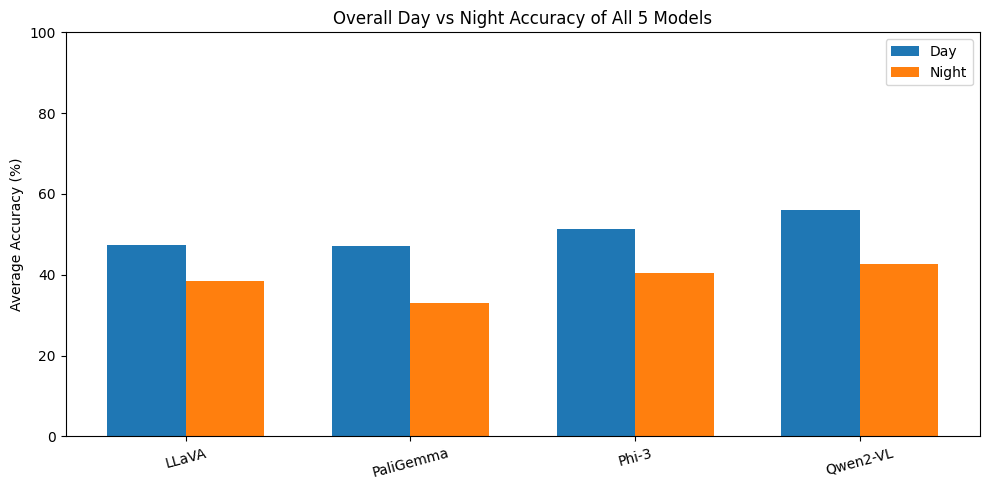

Saved: /kaggle/working/final_model_comparison/day_vs_night_overall_all_5_models.png


In [18]:
pivot_dn = day_night_overall.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

x = np.arange(len(pivot_dn))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, pivot_dn["day"], width, label="Day")
plt.bar(x + width/2, pivot_dn["night"], width, label="Night")

plt.xticks(x, pivot_dn["model"], rotation=15)
plt.ylabel("Average Accuracy (%)")
plt.title("Overall Day vs Night Accuracy of All 5 Models")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

dn_chart_path = os.path.join(OUTPUT_DIR, "day_vs_night_overall_all_5_models.png")
plt.savefig(dn_chart_path, dpi=200)
plt.show()

print("Saved:", dn_chart_path)

In [19]:
print("Final saved files:")
print(os.listdir(OUTPUT_DIR))

Final saved files:
['final_summary_table.csv', 'final_all_models_comparison.csv', 'overall_accuracy_all_5_models_line.png', 'overall_accuracy_all_5_models_bar.png', 'all_models_object_description.png', 'all_models_object_counting.png', 'overall_accuracy_all_5_models.csv', 'day_night_overall_all_5_models.csv', 'all_models_surrounding_description.png', 'all_5_models_combined_chart.png', 'day_vs_night_overall_all_5_models.png']


In [20]:
import os

save_dir = "/kaggle/working/notebook_code_backup"
os.makedirs(save_dir, exist_ok=True)

py_path = os.path.join(save_dir, "all_notebook_code.py")

with open(py_path, "w", encoding="utf-8") as f:
    for i, cell_code in enumerate(In):
        if isinstance(cell_code, str) and cell_code.strip():
            f.write(f"# =========================\n")
            f.write(f"# CELL {i}\n")
            f.write(f"# =========================\n\n")
            f.write(cell_code)
            f.write("\n\n")

print("Saved code file:", py_path)
print("Exists:", os.path.exists(py_path))

Saved code file: /kaggle/working/notebook_code_backup/all_notebook_code.py
Exists: True


In [21]:
import zipfile
import os

source_file = "/kaggle/working/notebook_code_backup/all_notebook_code.py"
zip_path = "/kaggle/working/notebook_code_backup.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(source_file, arcname="all_notebook_code.py")

print("ZIP created:", zip_path)
print("Exists:", os.path.exists(zip_path))
print("Files in /kaggle/working:")
print(os.listdir("/kaggle/working"))

ZIP created: /kaggle/working/notebook_code_backup.zip
Exists: True
Files in /kaggle/working:
['final_model_comparison', '.virtual_documents', 'notebook_code_backup', 'notebook_code_backup.zip']
